# 🎶 Applying a Clustering Algorithm to a Spotify Tracks dataset #

**Group**: Beatriz Alves (20241747), Inês Claro (20241760), Marta Silva (20241822)

**Objective**: 

-------------

## 1. Import Libraries ##

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import streamlit as st
import umap

spotify_green = '#1DB954'

## 2. Load Data ##

In [2]:
df_spotify = pd.read_csv("dataset.csv")

df_spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Exploratory Data Analysis ##

In [3]:
df_spotify.drop("Unnamed: 0", axis = 1, inplace = True) # drop the unnecessary column

print(f"Initial shape of the dataset: {df_spotify.shape}")

Initial shape of the dataset: (114000, 20)


In [4]:
df_spotify.isna().sum() # checking for missing values

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [5]:
df_spotify[df_spotify.isna().any(axis=1)] # displaying rows with missing values

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Since the missing values are all on the same row, that track will be removed.

In [6]:
df_spotify.dropna(inplace = True)

duplicates = df_spotify.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

df_spotify.drop_duplicates(inplace=True)

print(f"Shape of the dataset after duplicate removal: {df_spotify.shape}")

df_spotify.reset_index(drop=True,inplace = True)

Number of duplicate rows: 450
Shape of the dataset after duplicate removal: (113549, 20)


In [7]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113549 entries, 0 to 113548
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           11

In [8]:
audio_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
              'liveness', 'valence', 'tempo'] # only continuous features
df_spotify[audio_cols].describe().round(3)

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000
mean,33.324,228081.371,0.567,0.642,-8.243,0.085,0.314,0.156,0.214,0.474,122.176
std,22.284,106413.099,0.173,0.251,5.011,0.106,0.332,0.309,0.190,0.259,29.973
min,0.000,8586.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174184.000,0.456,0.473,-9.998,0.036,0.017,0.000,0.098,0.260,99.296
50%,35.000,213000.000,0.580,0.685,-6.997,0.049,0.168,0.000,0.132,0.464,122.020
75%,50.000,261588.000,0.695,0.854,-5.001,0.084,0.596,0.049,0.273,0.683,140.074
max,100.000,5237295.000,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


Only continuous features were considered here since those are the numeric variables where **mean**, **std** and **percentiles** make sense.

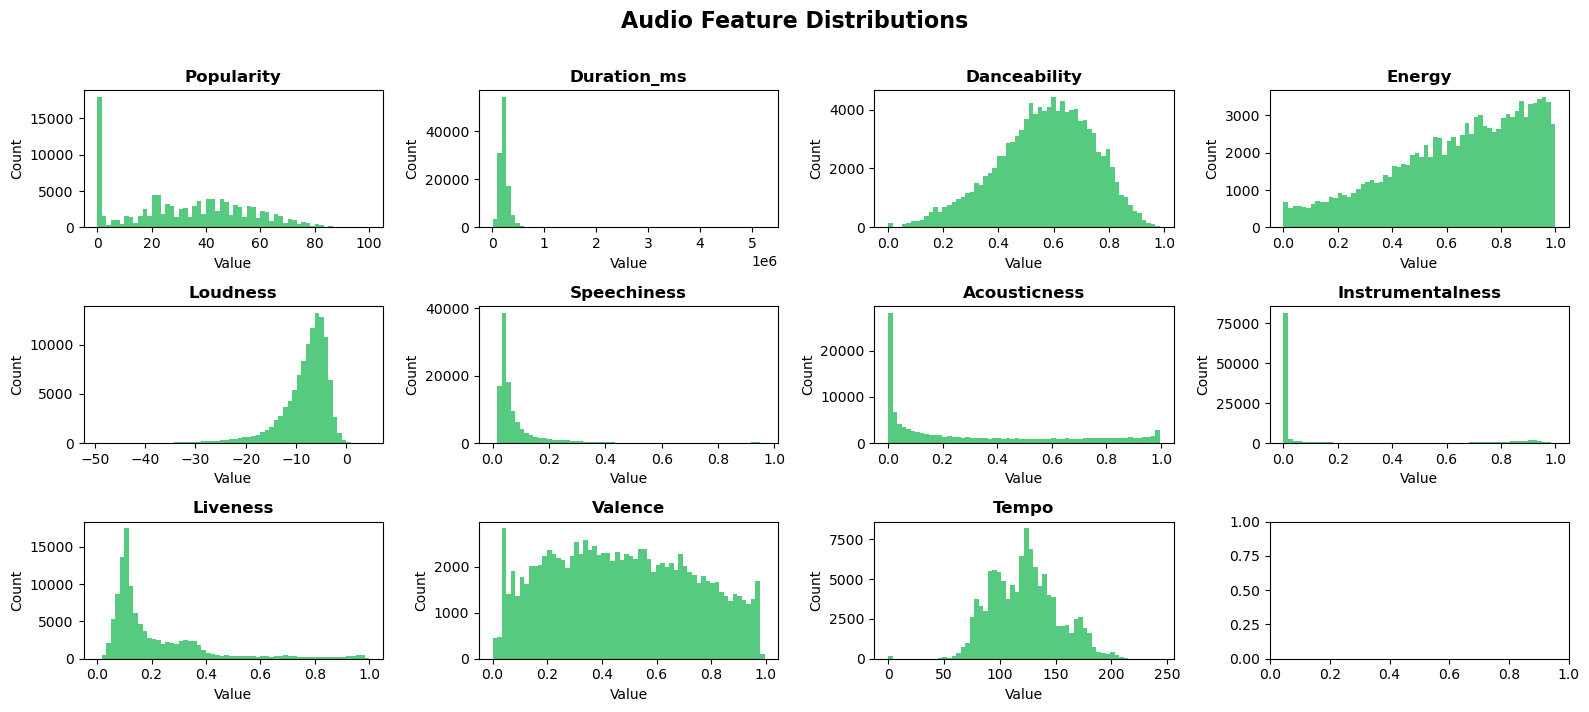

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 7)) # 12 plots for 11 features, meaning 1 will be empty
axes = axes.flatten()

for i, feat in enumerate(audio_cols):
    axes[i].hist(df_spotify[feat], bins=60, color=spotify_green, alpha=0.75, edgecolor='none')
    axes[i].set_title(feat.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Audio Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

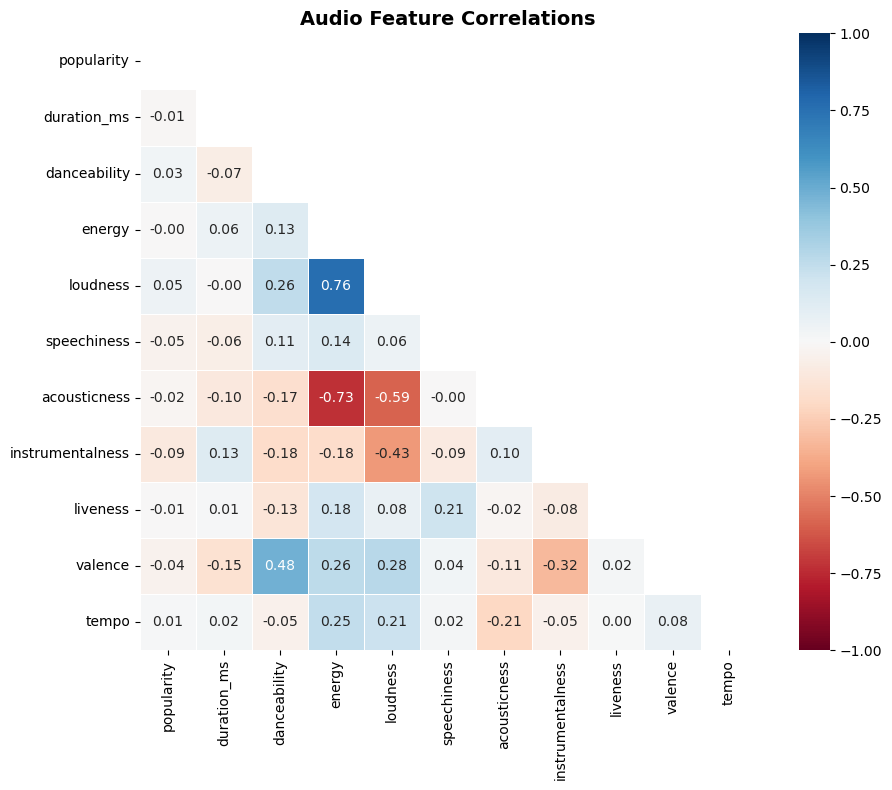

In [10]:
num_features = df_spotify[audio_cols]
corr = num_features.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Audio Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Key findings:
- `loudness` has a very strong correlation with both `energy` (0.76) and `acousticness` (-0.59)
- `acousticness` has a very strong correlation with both `energy` (-0.73) and `loudness` (-0.59)

Conclusions:
- both `loudness` and `acousticness` are not going to be considered for clustering

## 4. Feature Engineering ##

Features used for clustering:
  popularity
  danceability
  energy
  liveness
  valence
  tempo
  log_speechiness
  log_instrumentalness
  log_duration_ms


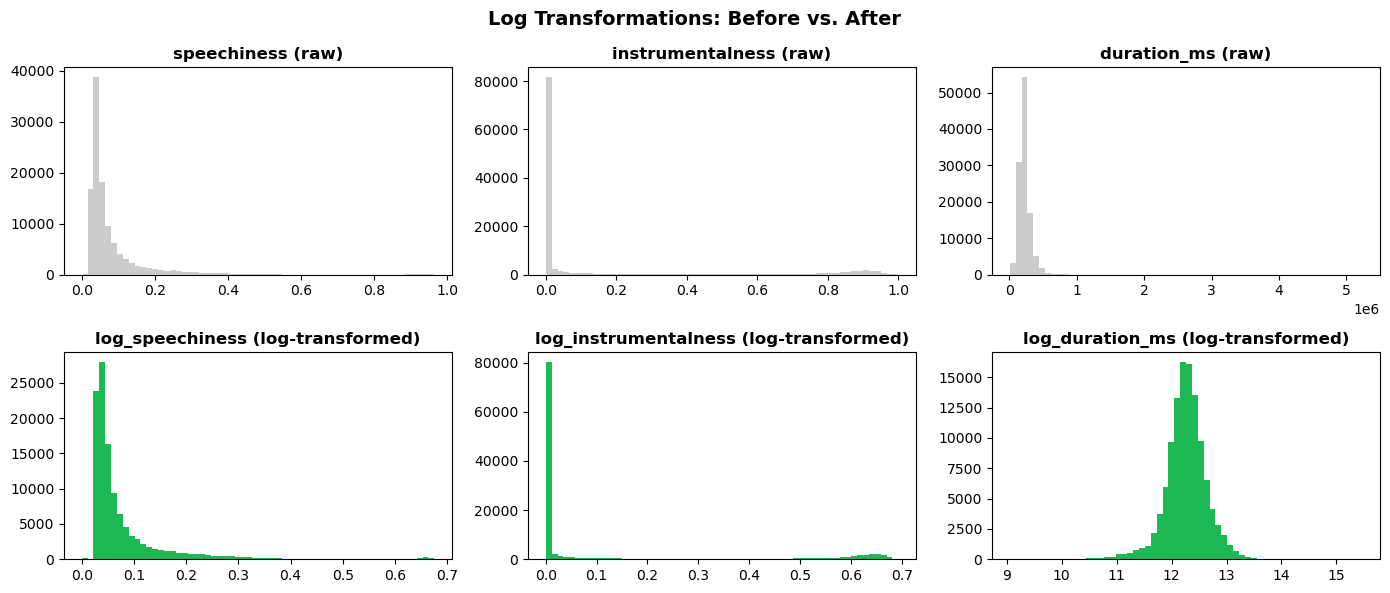

In [11]:
features = ['popularity', 'danceability', 'energy',
            'liveness', 'valence', 'tempo']

spotify_clustering = df_spotify[features].copy()

# transforming skewed features to reduce skewness and make them more suitable for clustering
spotify_clustering['log_speechiness']      = np.log1p(df_spotify['speechiness'])
spotify_clustering['log_instrumentalness'] = np.log1p(df_spotify['instrumentalness'])
spotify_clustering['log_duration_ms']      = np.log(df_spotify['duration_ms'])

print('Features used for clustering:')
for col in spotify_clustering.columns:
    print(f'  {col}')

# distribution before vs. after applying the log transformations
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, (raw, log) in enumerate([('speechiness', 'log_speechiness'),
                                  ('instrumentalness', 'log_instrumentalness'),
                                  ('duration_ms', 'log_duration_ms')]):
    axes[0, i].hist(df_spotify[raw], bins=60, color='#ccc', edgecolor='none')
    axes[0, i].set_title(f'{raw} (raw)', fontweight='bold')
    axes[1, i].hist(spotify_clustering[log], bins=60, color=spotify_green, edgecolor='none')
    axes[1, i].set_title(f'{log} (log-transformed)', fontweight='bold')

plt.suptitle('Log Transformations: Before vs. After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Scaling and applying the algorithms ##

In [12]:
scaler = RobustScaler() # using RobustScaler to reduce the influence of outliers
spotify_clustering_scaled = scaler.fit_transform(spotify_clustering)

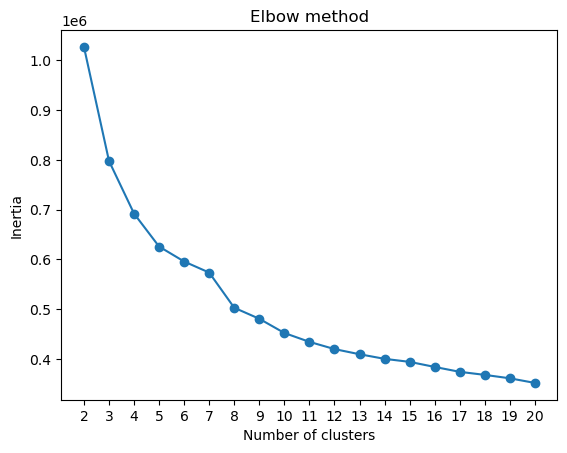

In [13]:
inertias = []

for i in range(2,21):
    kmeans = KMeans(n_clusters=i, random_state = 0)
    kmeans.fit(spotify_clustering_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2,21), inertias, marker='o')
plt.title('Elbow method')
plt.xticks(range(2,21))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [14]:
inertias, sil_scores = {}, {}
for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(spotify_clustering_scaled)
    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(spotify_clustering_scaled, labels, sample_size=6000, random_state=0)
    print(f'  K={k:2d}  |  Inertia: {km.inertia_:,.0f}  |  Silhouette: {sil_scores[k]:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\n✅ Best K by silhouette: {best_k} (score={sil_scores[best_k]:.4f})')

  K= 2  |  Inertia: 1,026,968  |  Silhouette: 0.6913
  K= 3  |  Inertia: 797,795  |  Silhouette: 0.5186
  K= 4  |  Inertia: 692,053  |  Silhouette: 0.4925
  K= 5  |  Inertia: 625,789  |  Silhouette: 0.3439
  K= 6  |  Inertia: 595,728  |  Silhouette: 0.3199
  K= 7  |  Inertia: 573,483  |  Silhouette: 0.3013
  K= 8  |  Inertia: 502,800  |  Silhouette: 0.2161
  K= 9  |  Inertia: 480,681  |  Silhouette: 0.1995
  K=10  |  Inertia: 452,132  |  Silhouette: 0.1629
  K=11  |  Inertia: 434,294  |  Silhouette: 0.1582
  K=12  |  Inertia: 419,772  |  Silhouette: 0.1557
  K=13  |  Inertia: 409,430  |  Silhouette: 0.1536
  K=14  |  Inertia: 400,163  |  Silhouette: 0.1492
  K=15  |  Inertia: 394,088  |  Silhouette: 0.1508
  K=16  |  Inertia: 383,903  |  Silhouette: 0.1485
  K=17  |  Inertia: 374,061  |  Silhouette: 0.1469
  K=18  |  Inertia: 367,924  |  Silhouette: 0.1442
  K=19  |  Inertia: 361,075  |  Silhouette: 0.1440
  K=20  |  Inertia: 351,772  |  Silhouette: 0.1458

✅ Best K by silhouette: 2 (s

In [15]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(spotify_clustering_scaled)
spotify_clustering['cluster_kmeans'] = kmeans.predict(spotify_clustering_scaled)

In [16]:
spotify_clustering.groupby('cluster_kmeans').mean()

,popularity,danceability,energy,liveness,valence,tempo,log_speechiness,log_instrumentalness,log_duration_ms
cluster_kmeans,,,,,,,,,
0,34.251508,0.580811,0.660545,0.220345,0.511980,122.745764,0.080794,0.013419,12.253421
1,29.208948,0.505862,0.560171,0.183726,0.306516,119.645310,0.062881,0.573065,12.314320


**Cluster 0**:
- more popular songs
- more danceable and energetic songs
- slightly higher liveness, valence and tempo
- higher speechiness

**Cluster 1**: 
- less popular songs
- more instrumental
- with slightly more duration

`valence` and `log_instrumentalness` are the main variables that mainly separate both clusters.

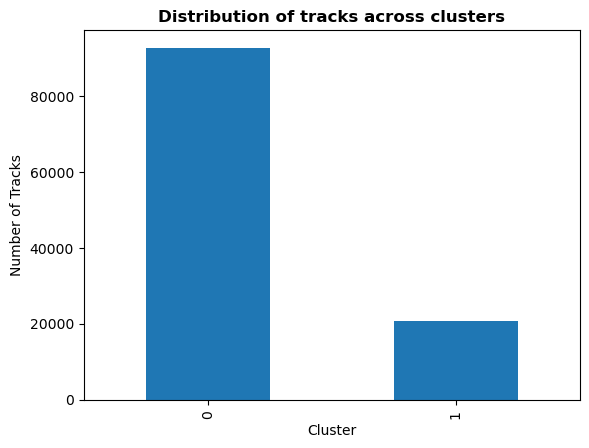

In [17]:
spotify_clustering.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Distribution of tracks across clusters', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Tracks')
plt.show()

**Cluster 0** is the cluster with more tracks.

In [18]:
silhouette_avg = silhouette_score(spotify_clustering_scaled, spotify_clustering['cluster_kmeans']) # calculating silhouette score for the final clustering solution
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.6905


### UMAP - Dimensionality Reduction

In [19]:
# Apply UMAP with 2 components for visualization
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_embeddings = umap_reducer.fit_transform(spotify_clustering_scaled)

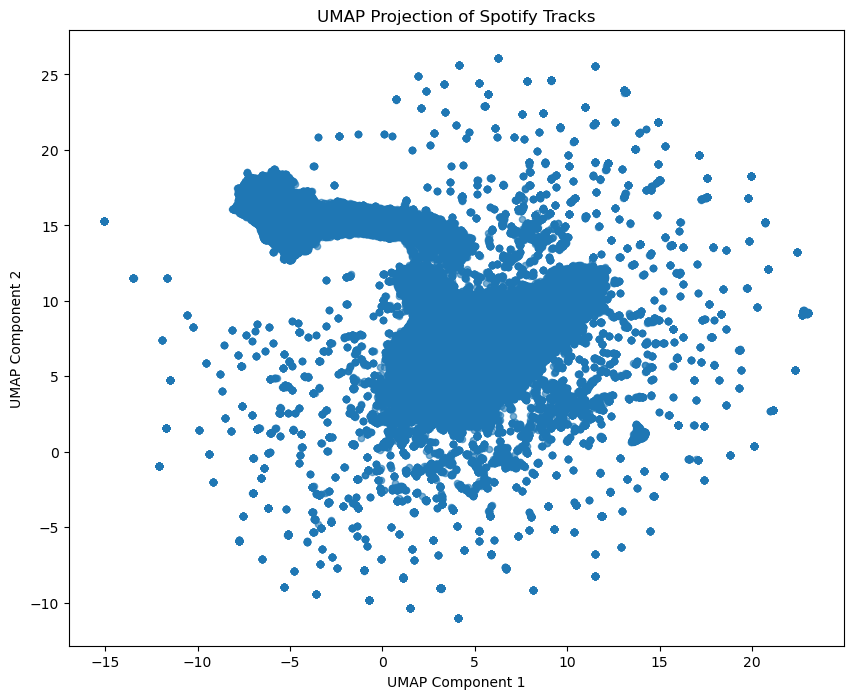

In [21]:
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], alpha=0.6, s=20)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP Projection of Spotify Tracks')
plt.show()

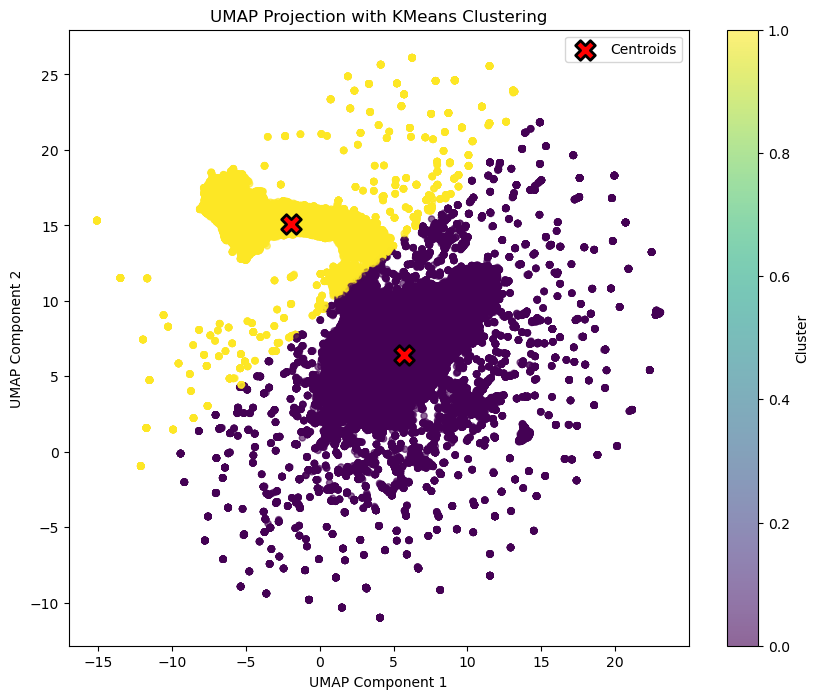

In [25]:
# Apply KMeans clustering on UMAP embeddings (using optimal number of clusters)
kmeans_umap = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_umap = kmeans_umap.fit_predict(umap_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=clusters_umap, cmap='viridis', alpha=0.6, s=20)
plt.scatter(kmeans_umap.cluster_centers_[:, 0], kmeans_umap.cluster_centers_[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP Projection with KMeans Clustering')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

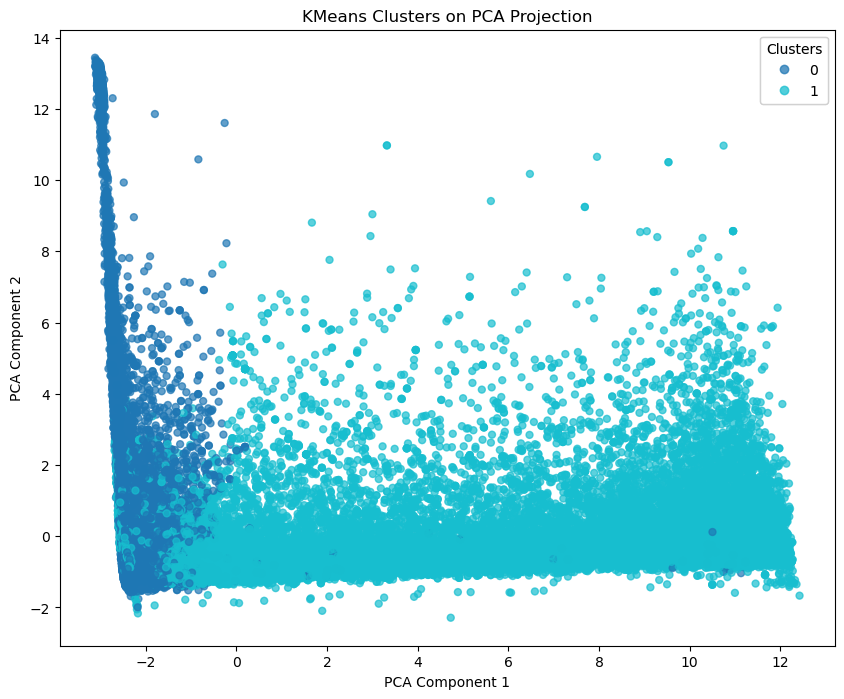

In [27]:
pca = PCA(n_components=2, random_state=42)
pca_embeddings = pca.fit_transform(spotify_clustering_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    pca_embeddings[:, 0],
    pca_embeddings[:, 1],
    c=clusters_umap,
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters on PCA Projection')

legend1 = plt.legend(*scatter.legend_elements(),
                     title="Clusters")
plt.gca().add_artist(legend1)

plt.show()